# Utilidades y plantillas para OpenCV

**Duración estimada:** 45 minutos de exploración guiada + uso libre durante el TPI

## Objetivo

Este cuaderno reúne funciones de apoyo para la unidad `004 - openCV`. La idea no es reemplazar a los cuadernos teórico-prácticos, sino darte una caja de herramientas clara, breve y reutilizable para que puedas trabajar con menos fricción en los ejercicios y en el Trabajo Práctico Integrador.

## Resultados de aprendizaje

Al final de este cuaderno vas a poder:

- cargar imágenes locales o descargarlas si faltan;
- visualizarlas con ejes y coordenadas legibles;
- recortar regiones y comparar resultados;
- crear y limpiar máscaras binarias;
- probar restauración rápida con `inpaint`;
- reutilizar plantillas de código sin perder de vista qué hace cada paso.

## Relación con cuadernos anteriores

Este cuaderno acompaña toda la secuencia de `004 - openCV`, especialmente:

- `001 - introduccion a opencv y espacios de color.ipynb`
- `004b - operaciones basicas con imagenes.ipynb`
- `006b - filtros de suavizado y reduccion de ruido.ipynb`
- `006c - morfologia matematica para limpieza de mascaras.ipynb`
- `006d - restauracion y algoritmos de inpainting.ipynb`

## Cómo conviene usar este cuaderno

- Podés ejecutarlo completo una vez para dejar disponibles todas las funciones.
- Después podés volver a copiar solo los bloques que necesites en otro notebook.
- La idea no es usar estas funciones como caja negra. Fijate siempre qué reciben, qué devuelven y qué decisión técnica esconden.


## 1. Concepto: una caja de herramientas no piensa por vos

Tener funciones listas acelera el trabajo, pero también puede generar una ilusión peligrosa: creer que la técnica ya está resuelta solo porque el código corre.

En procesamiento digital de imágenes, una función puede estar bien escrita y aun así ser una mala decisión para el problema que tenés delante.

[Pregunta para pensar]

Si dos estudiantes usan exactamente la misma función, ¿por qué uno puede obtener una restauración razonable y otro una muy mala? La diferencia no está solo en el código: está en cómo interpretan la imagen, los parámetros y el objetivo.


In [1]:
from pathlib import Path
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt


CARPETA_IMAGENES = Path("Imagenes")
CARPETA_IMAGENES.mkdir(exist_ok=True)

URLS_REFERENCIA = {
    "lena.jpg": "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/lena.jpg",
    "notes.png": "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/notes.png",
    "building.jpg": "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/building.jpg",
}


def descargar_si_falta(nombre_archivo):
    '''Descarga una imagen de referencia solo si todavía no existe en la carpeta Imagenes.'''
    ruta = CARPETA_IMAGENES / nombre_archivo

    if ruta.exists():
        print(f"La imagen ya estaba disponible en: {ruta}")
        return ruta

    if nombre_archivo not in URLS_REFERENCIA:
        raise FileNotFoundError(
            f"No encontré '{nombre_archivo}' y tampoco hay una URL registrada para descargarlo."
        )

    print(f"Descargando {nombre_archivo}...")
    urllib.request.urlretrieve(URLS_REFERENCIA[nombre_archivo], ruta)
    print(f"Imagen descargada en: {ruta}")
    return ruta


def abrir_imagen_bgr(nombre_archivo):
    '''Abre una imagen en BGR usando OpenCV. Si falta y existe URL, la descarga.'''
    ruta = CARPETA_IMAGENES / nombre_archivo
    if not ruta.exists() and nombre_archivo in URLS_REFERENCIA:
        ruta = descargar_si_falta(nombre_archivo)

    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No pude abrir la imagen: {ruta}")
    return imagen_bgr


def abrir_imagen_rgb(nombre_archivo):
    '''Abre una imagen y la convierte a RGB para mostrarla con Matplotlib.'''
    imagen_bgr = abrir_imagen_bgr(nombre_archivo)
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    '''Muestra una imagen con ejes visibles para leer coordenadas y escalas.'''
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(40, ancho // 6)
    paso_y = max(40, alto // 6)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_una_imagen(imagen, titulo, mapa=None, tamano=(8, 6)):
    '''Muestra una sola imagen con coordenadas visibles.'''
    figura, eje = plt.subplots(figsize=tamano, constrained_layout=True)
    preparar_eje_imagen(eje, imagen, titulo, mapa)
    plt.show()


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(16, 5)):
    '''Muestra varias imágenes lado a lado con un formato consistente.'''
    if mapas is None:
        mapas = [None] * len(imagenes)

    figura, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def mostrar_info_imagen(imagen, titulo="Imagen"):
    '''Imprime datos básicos de una imagen para inspección rápida.'''
    print(f"{titulo}:")
    print(f"  Forma: {imagen.shape}")
    print(f"  Tipo de dato: {imagen.dtype}")
    print(f"  Valor mínimo: {imagen.min()}")
    print(f"  Valor máximo: {imagen.max()}")


def recortar_region(imagen, x_inicio, y_inicio, ancho, alto):
    '''Devuelve un recorte rectangular usando coordenadas x e y.'''
    return imagen[y_inicio:y_inicio + alto, x_inicio:x_inicio + ancho]


def comparar_antes_despues(imagen_antes, imagen_despues, titulo_antes="Antes", titulo_despues="Después"):
    '''Muestra una comparación simple lado a lado.'''
    mostrar_varias_imagenes(
        [imagen_antes, imagen_despues],
        [titulo_antes, titulo_despues],
        tamano=(14, 5),
    )


def convertir_a_grises(imagen_bgr):
    '''Convierte una imagen BGR a escala de grises.'''
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)


def convertir_a_hsv(imagen_bgr):
    '''Convierte una imagen BGR a HSV.'''
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)


def convertir_a_lab(imagen_bgr):
    '''Convierte una imagen BGR a Lab.'''
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2LAB)


def crear_mascara_por_rango_hsv(imagen_hsv, limite_inferior, limite_superior):
    '''Crea una máscara binaria para un rango de color en HSV.'''
    return cv2.inRange(imagen_hsv, limite_inferior, limite_superior)


def aplicar_mascara(imagen_rgb, mascara_binaria):
    '''Aplica una máscara binaria sobre una imagen RGB.'''
    return cv2.bitwise_and(imagen_rgb, imagen_rgb, mask=mascara_binaria)


def limpiar_mascara_morfologia(mascara_binaria, operacion="apertura", tamano_kernel=5, iteraciones=1):
    '''Aplica una operación morfológica básica sobre una máscara binaria.'''
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (tamano_kernel, tamano_kernel))

    if operacion == "erosion":
        return cv2.erode(mascara_binaria, kernel, iterations=iteraciones)
    if operacion == "dilatacion":
        return cv2.dilate(mascara_binaria, kernel, iterations=iteraciones)
    if operacion == "apertura":
        return cv2.morphologyEx(mascara_binaria, cv2.MORPH_OPEN, kernel, iterations=iteraciones)
    if operacion == "clausura":
        return cv2.morphologyEx(mascara_binaria, cv2.MORPH_CLOSE, kernel, iterations=iteraciones)

    raise ValueError("La operación debe ser: erosion, dilatacion, apertura o clausura.")


def crear_mascara_de_rayones(imagen_rgb):
    '''Genera una máscara de daño simple para ensayar restauración con inpainting.'''
    alto, ancho = imagen_rgb.shape[:2]
    mascara = np.zeros((alto, ancho), dtype=np.uint8)

    cv2.line(mascara, (40, 40), (ancho - 80, alto - 60), 255, 4)
    cv2.line(mascara, (ancho // 3, 20), (ancho // 2, alto - 30), 255, 3)
    cv2.putText(mascara, "Danio", (50, alto // 2), cv2.FONT_HERSHEY_SIMPLEX, 1.0, 255, 3, cv2.LINE_AA)
    return mascara


def superponer_dano(imagen_rgb, mascara_dano):
    '''Genera una imagen dañada a partir de una máscara de rayones o faltantes.'''
    imagen_danada = imagen_rgb.copy()
    imagen_danada[mascara_dano == 255] = [245, 245, 245]
    return imagen_danada


def restaurar_con_inpainting(imagen_rgb, mascara_dano, radio=3, metodo="telea"):
    '''Restaura una imagen dañada con alguno de los métodos de inpainting de OpenCV.'''
    imagen_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    if metodo == "telea":
        bandera = cv2.INPAINT_TELEA
    elif metodo == "ns":
        bandera = cv2.INPAINT_NS
    else:
        raise ValueError("El método debe ser 'telea' o 'ns'.")

    restaurada_bgr = cv2.inpaint(imagen_bgr, mascara_dano, radio, bandera)
    restaurada_rgb = cv2.cvtColor(restaurada_bgr, cv2.COLOR_BGR2RGB)
    return restaurada_rgb


def calcular_error_medio_absoluto(imagen_referencia, imagen_prueba):
    '''Calcula una medida simple de diferencia promedio entre dos imágenes.'''
    diferencia = np.abs(imagen_referencia.astype(np.float32) - imagen_prueba.astype(np.float32))
    return diferencia.mean()


print("Funciones listas para usar.")
print("Este cuaderno está pensado como referencia rápida para la unidad 004.")


Funciones listas para usar.
Este cuaderno está pensado como referencia rápida para la unidad 004.


## 2. Ejercicio manual: visualizar, leer coordenadas y recortar

Esta primera plantilla sirve para tres tareas muy frecuentes:

- verificar que una imagen cargó bien;
- leer coordenadas con ejes visibles;
- recortar una región para mirarla con más detalle.

Vamos a usar `small-boats_1.jpg`, que ya venías trabajando en otros materiales de la unidad.


Imagen de barcos:
  Forma: (795, 1200, 3)
  Tipo de dato: uint8
  Valor mínimo: 0
  Valor máximo: 255


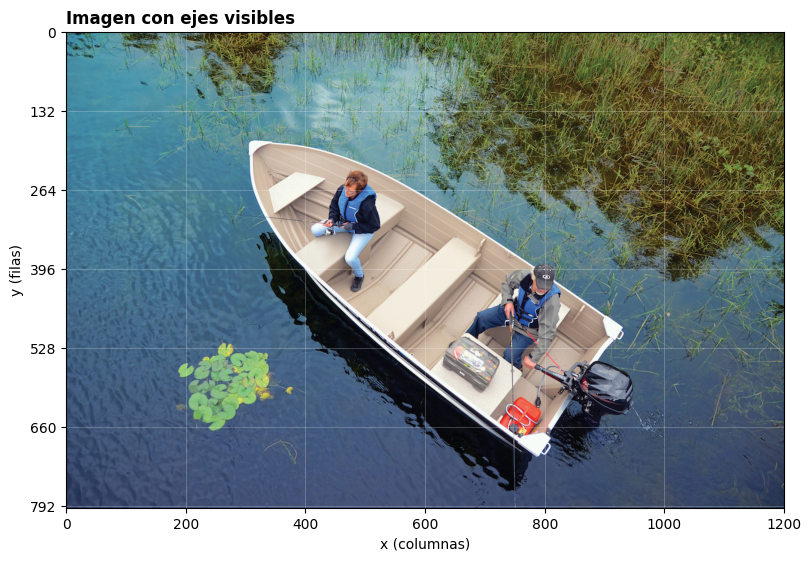

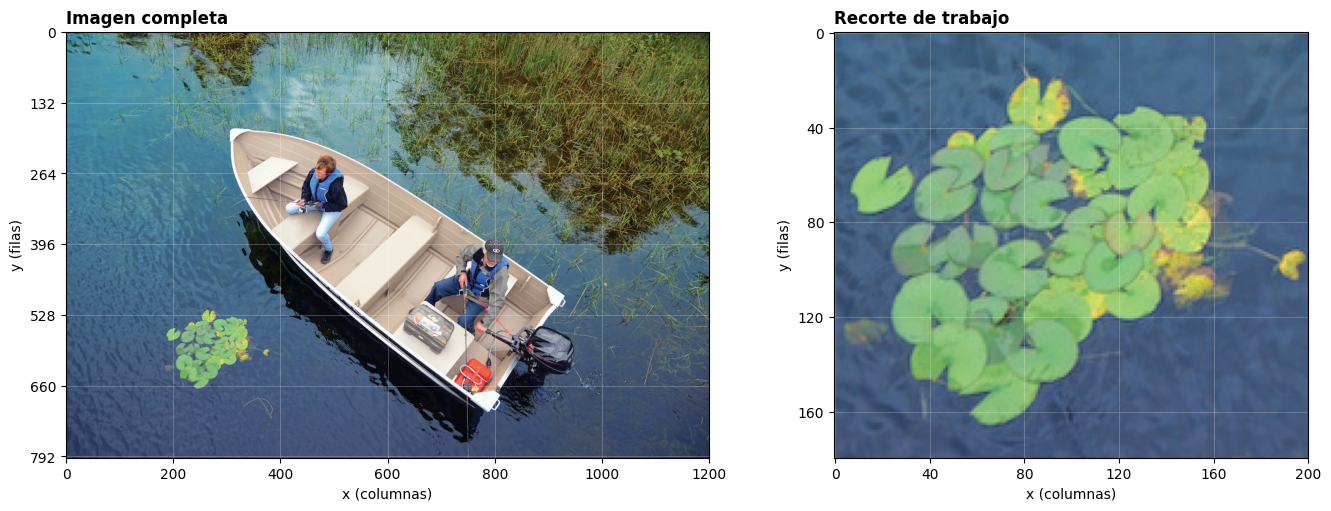

In [2]:
imagen_boats = abrir_imagen_rgb("small-boats_1.jpg")
mostrar_info_imagen(imagen_boats, "Imagen de barcos")
mostrar_una_imagen(imagen_boats, "Imagen con ejes visibles")

recorte_barcos = recortar_region(imagen_boats, x_inicio=180, y_inicio=500, ancho=200, alto=180)
comparar_antes_despues(imagen_boats, recorte_barcos, "Imagen completa", "Recorte de trabajo")


**Qué observar**

- Los ejes ayudan a leer coordenadas con precisión.
- El recorte mantiene solo una porción de la escena y facilita el análisis local.

**Qué conclusión se puede sacar**

- Muchas decisiones del pipeline dependen de saber exactamente dónde está una región problemática.

**Qué limitación tiene este ejemplo**

- Un recorte no resuelve nada por sí solo. Solo reduce el campo visual para trabajar mejor.


## 3. Automatización con Python: conversión de espacios de color y máscaras rápidas

Ahora vamos a usar una imagen de globos para mostrar dos tareas muy habituales:

- convertir una imagen a otro espacio de color;
- crear una máscara binaria por rango en `HSV`.


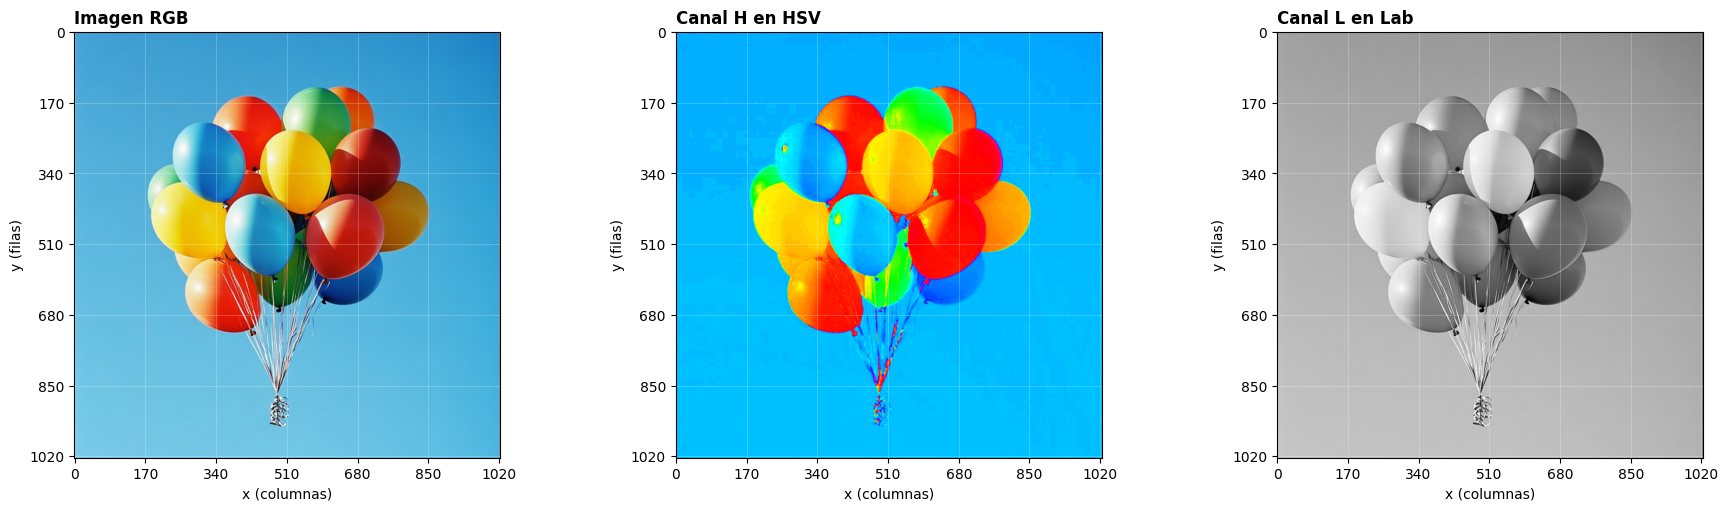

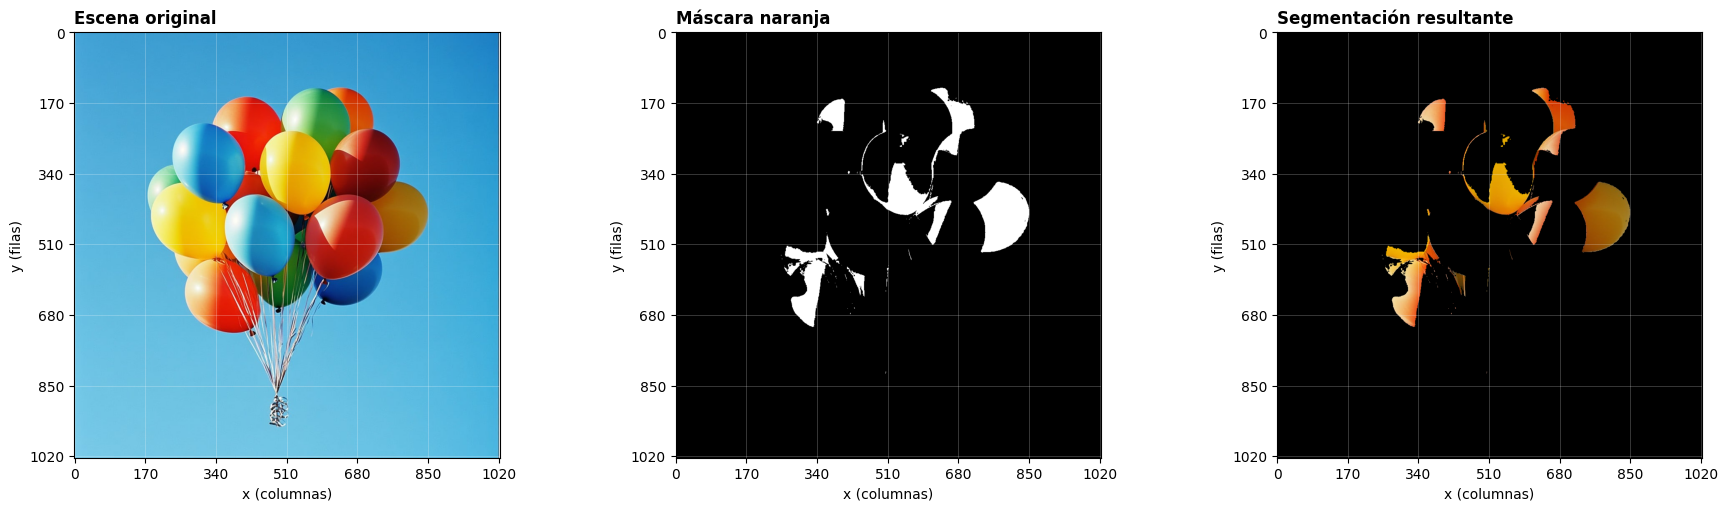

In [3]:
imagen_globos_bgr = abrir_imagen_bgr("globos.jpg")
imagen_globos_rgb = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2RGB)
imagen_globos_hsv = convertir_a_hsv(imagen_globos_bgr)
imagen_globos_lab = convertir_a_lab(imagen_globos_bgr)

canal_l = imagen_globos_lab[:, :, 0]

mostrar_varias_imagenes(
    [imagen_globos_rgb, imagen_globos_hsv[:, :, 0], canal_l],
    ["Imagen RGB", "Canal H en HSV", "Canal L en Lab"],
    [None, "hsv", "gray"],
    tamano=(18, 5),
)

limite_inferior_naranja = np.array([8, 80, 80])
limite_superior_naranja = np.array([22, 255, 255])

mascara_naranja = crear_mascara_por_rango_hsv(
    imagen_globos_hsv,
    limite_inferior_naranja,
    limite_superior_naranja,
)
segmentacion_naranja = aplicar_mascara(imagen_globos_rgb, mascara_naranja)

mostrar_varias_imagenes(
    [imagen_globos_rgb, mascara_naranja, segmentacion_naranja],
    ["Escena original", "Máscara naranja", "Segmentación resultante"],
    [None, "gray", None],
    tamano=(18, 5),
)


**Qué observar**

- El mismo contenido visual cambia mucho según el espacio de color elegido.
- La máscara binaria traduce una decisión sobre color a una forma utilizable por el algoritmo.

**Qué conclusión podés sacar**

- Una buena función utilitaria te ahorra tiempo, pero la elección del rango sigue siendo conceptual y depende del problema.

**Qué limitación tiene este paso**

- Un rango que funciona bien en esta imagen puede fallar por completo en otra con distinta iluminación.


## 4. Ejemplo práctico: limpiar una máscara con morfología matemática

Esta plantilla resume una tarea muy frecuente: tomar una máscara sucia y aplicar apertura o clausura según el problema.


La imagen ya estaba disponible en: Imagenes\notes.png


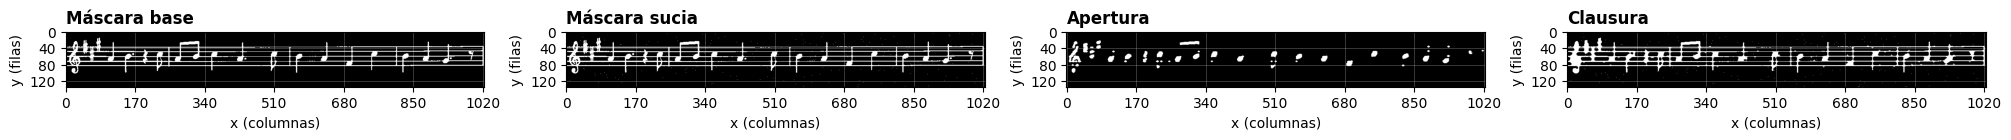

In [4]:
descargar_si_falta("notes.png")
imagen_notas_bgr = abrir_imagen_bgr("notes.png")
imagen_notas_gris = convertir_a_grises(imagen_notas_bgr)

_, mascara_base = cv2.threshold(
    imagen_notas_gris,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU,
)

generador = np.random.default_rng(17)
mascara_sucia = mascara_base.copy()

posiciones_fondo = np.argwhere(mascara_sucia == 0)
indices_ruido = generador.choice(len(posiciones_fondo), size=200, replace=False)
for indice in indices_ruido:
    y, x = posiciones_fondo[indice]
    mascara_sucia[y, x] = 255

mascara_apertura = limpiar_mascara_morfologia(mascara_sucia, operacion="apertura", tamano_kernel=5)
mascara_clausura = limpiar_mascara_morfologia(mascara_sucia, operacion="clausura", tamano_kernel=5)

mostrar_varias_imagenes(
    [mascara_base, mascara_sucia, mascara_apertura, mascara_clausura],
    ["Máscara base", "Máscara sucia", "Apertura", "Clausura"],
    ["gray", "gray", "gray", "gray"],
    tamano=(20, 5),
)


**Qué observar**

- La apertura tiende a borrar ruido blanco aislado.
- La clausura tiende a cerrar huecos y reforzar continuidad.

**Qué conclusión se puede sacar**

- No existe una limpieza universal de máscaras: depende de si el problema es ruido externo o agujeros internos.

**Qué limitación tiene este ejemplo**

- Si el kernel es demasiado grande, la máscara puede deformarse demasiado.


## 5. Plantilla rápida para restauración con inpainting

Esta plantilla está pensada para ensayos iniciales de restauración: crear una máscara de daño, generar una imagen dañada y comparar restauraciones con `TELEA` y `NS`.


La imagen ya estaba disponible en: Imagenes\building.jpg


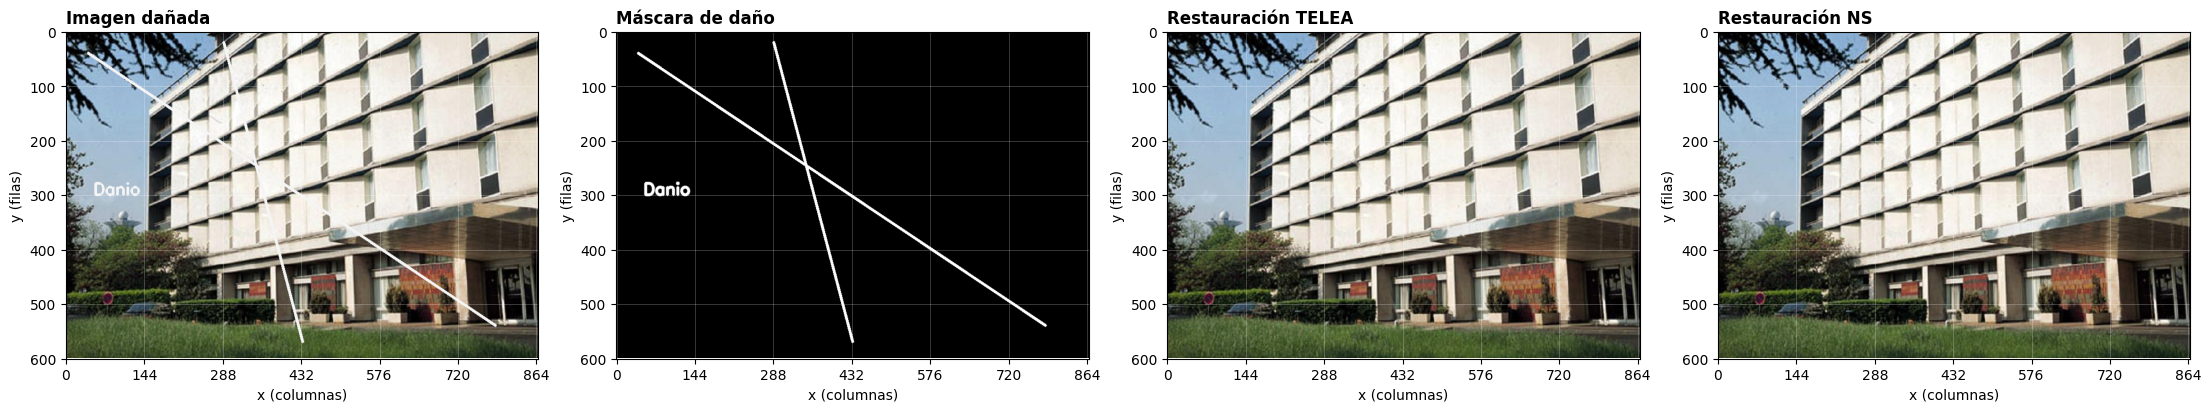

Error medio absoluto TELEA: 0.19
Error medio absoluto NS: 0.15


In [5]:
descargar_si_falta("building.jpg")
imagen_edificio = abrir_imagen_rgb("building.jpg")

mascara_dano = crear_mascara_de_rayones(imagen_edificio)
imagen_danada = superponer_dano(imagen_edificio, mascara_dano)

restauracion_telea = restaurar_con_inpainting(imagen_danada, mascara_dano, radio=3, metodo="telea")
restauracion_ns = restaurar_con_inpainting(imagen_danada, mascara_dano, radio=3, metodo="ns")

mostrar_varias_imagenes(
    [imagen_danada, mascara_dano, restauracion_telea, restauracion_ns],
    ["Imagen dañada", "Máscara de daño", "Restauración TELEA", "Restauración NS"],
    [None, "gray", None, None],
    tamano=(22, 5),
)

print("Error medio absoluto TELEA:", round(calcular_error_medio_absoluto(imagen_edificio, restauracion_telea), 2))
print("Error medio absoluto NS:", round(calcular_error_medio_absoluto(imagen_edificio, restauracion_ns), 2))


**Qué observar**

- La máscara marca exactamente dónde el algoritmo debe reconstruir.
- Los dos métodos no siempre producen la misma continuidad visual.

**Qué conclusión podés sacar**

- Una utilidad bien diseñada hace que probar alternativas sea rápido y comparable.

**Qué limitación tiene esta plantilla**

- El hecho de que una restauración se vea plausible no garantiza fidelidad histórica ni documental.


## 6. Plantillas mínimas para copiar al TPI

Acá tenés tres esqueletos muy breves para reutilizar. La idea es que no copies y pegues a ciegas: mirá cada paso y adaptalo al problema real.


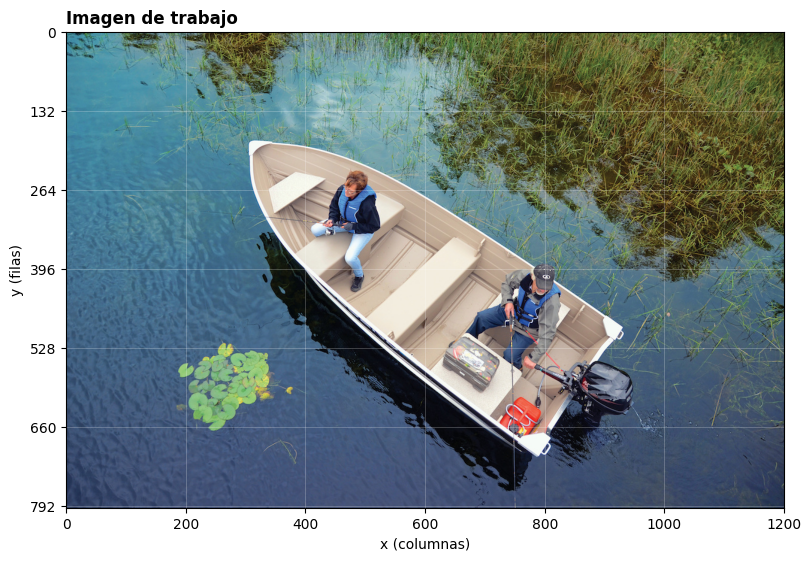

In [6]:
# PLANTILLA 1: cargar y mostrar una imagen con ejes
imagen_rgb = abrir_imagen_rgb("small-boats_1.jpg")
mostrar_una_imagen(imagen_rgb, "Imagen de trabajo")

# PLANTILLA 2: crear una máscara por rango en HSV
imagen_bgr = abrir_imagen_bgr("globos.jpg")
imagen_hsv = convertir_a_hsv(imagen_bgr)
mascara = crear_mascara_por_rango_hsv(
    imagen_hsv,
    np.array([8, 80, 80]),
    np.array([22, 255, 255]),
)

# PLANTILLA 3: limpiar la máscara y aplicarla
mascara_limpia = limpiar_mascara_morfologia(mascara, operacion="apertura", tamano_kernel=5)
segmentacion = aplicar_mascara(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB), mascara_limpia)


## 7. Limitaciones y próximos pasos

Esta caja de herramientas puede acelerar mucho el trabajo, pero no reemplaza el análisis.

- Una función correcta puede estar mal usada.
- Un parámetro pequeño puede cambiar por completo el resultado.
- Una restauración convincente visualmente puede ser metodológicamente débil.

**Actividad breve**

Elegí una sola función del cuaderno y probala sobre dos imágenes distintas de `004 - openCV/Imagenes/`. Después escribí qué cambió y por qué la misma herramienta no dio exactamente el mismo resultado.

**Cierre**

Si usás este cuaderno durante el TPI, tratá de que cada función venga acompañada de una decisión explícita: por qué la elegiste, con qué parámetros y qué limitación encontraste.


## Glosario de términos clave

**BGR**
Orden de canales que usa OpenCV cuando carga una imagen color: azul, verde y rojo.

**RGB**
Orden más habitual para mostrar imágenes en Matplotlib: rojo, verde y azul.

**Píxel**
Unidad mínima de una imagen digital. Cada píxel guarda uno o más valores numéricos.

**Canal**
Una capa de información dentro de una imagen. En color, cada canal suele representar una componente cromática.

**Máscara binaria**
Imagen de dos valores que separa regiones de interés del resto del fondo.

**Umbralización**
Operación que convierte una imagen en una máscara según una condición de intensidad.

**HSV**
Espacio de color que separa matiz, saturación y valor. Suele ser útil para segmentar por color.

**Lab**
Espacio de color que separa luminancia de información cromática. Puede ser útil para análisis perceptual.

**Kernel**
Pequeña ventana o estructura local que define cómo una operación recorre la imagen.

**Erosión**
Operación morfológica que reduce regiones blancas en una máscara.

**Dilatación**
Operación morfológica que expande regiones blancas en una máscara.

**Apertura**
Secuencia de erosión y dilatación. Suele servir para eliminar ruido blanco pequeño.

**Clausura**
Secuencia de dilatación y erosión. Suele servir para cerrar pequeños huecos negros.

**Ruido**
Variación espuria en la imagen que no forma parte útil de la escena o del documento.

**Recorte**
Selección de una región rectangular de la imagen para observarla o procesarla aparte.

**Inpainting**
Técnica de reconstrucción local que intenta rellenar regiones dañadas a partir del contexto vecino.

**`cv2.INPAINT_TELEA`**
Método de OpenCV para inpainting que suele dar resultados rápidos y visualmente limpios en muchos casos.

**`cv2.INPAINT_NS`**
Método de OpenCV inspirado en continuidad de estructuras, útil para comparar otro modo de reconstrucción.

**Error medio absoluto**
Medida simple que resume cuánto difiere una imagen procesada de una referencia, píxel a píxel, en promedio.

**Pipeline**
Secuencia de pasos encadenados para resolver un problema de procesamiento o restauración.
